In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from utils.evaluation import evaluate_pipeline
from utils import column_type_split, feature_importance_df

In [12]:
df = pd.read_csv("../data/train_clear.csv")

In [13]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [14]:
columns = column_type_split(X)

In [15]:
def get_pipeline(model) -> Pipeline:
    return Pipeline(
        [
            (
                "preprocess",
                ColumnTransformer(
                    [
                        (
                            "ordinal",
                            OrdinalEncoder(
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                                dtype=np.int64,
                            ),
                            columns.categorical,
                        )
                    ],
                    remainder="passthrough",
                ),
            ),
            (model.__class__.__name__, model),
        ]
    )

In [16]:
pipeline_xgb = get_pipeline(XGBClassifier())

Модель XGBClassifier
F1-macro: 0.834 ± 0.006
F1-weighted: 0.878 ± 0.004


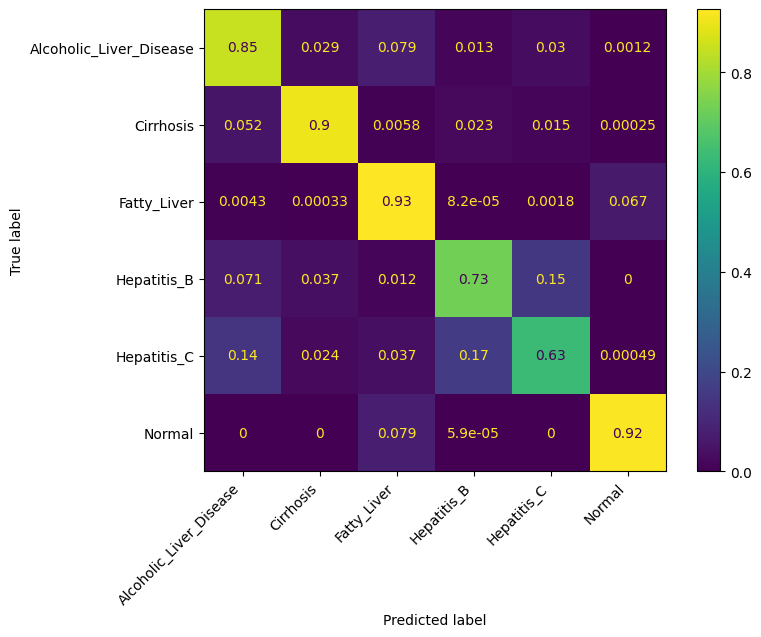

In [17]:
feature_importance_xgb = evaluate_pipeline(pipeline_xgb, X, y, additional="feature_importances_")

In [18]:
names = pipeline_xgb[0].get_feature_names_out()
feature_importance_df(feature_importance_xgb, names).head(10)

,feature,importance
14,remainder__Sym_Ascites,0.182857
10,remainder__Sym_Fatigue,0.160396
15,remainder__Sym_Dark_Urine,0.144395
11,remainder__Sym_Jaundice,0.107756
20,remainder__ALT,0.067754
22,remainder__Bilirubin,0.050679
21,remainder__AST,0.048422
17,remainder__Comorb_Diabetes,0.047023
12,remainder__Sym_Abdominal_Pain,0.037403
13,remainder__Sym_Itching,0.032120


Градиентный бустинг xgboost выдал точность выше чем деревья решений. Для него симптомы являются более важными признаками, чем ферменты

In [19]:
pipeline_gbc = get_pipeline(GradientBoostingClassifier())

Модель GradientBoostingClassifier
F1-macro: 0.814 ± 0.005
F1-weighted: 0.868 ± 0.003


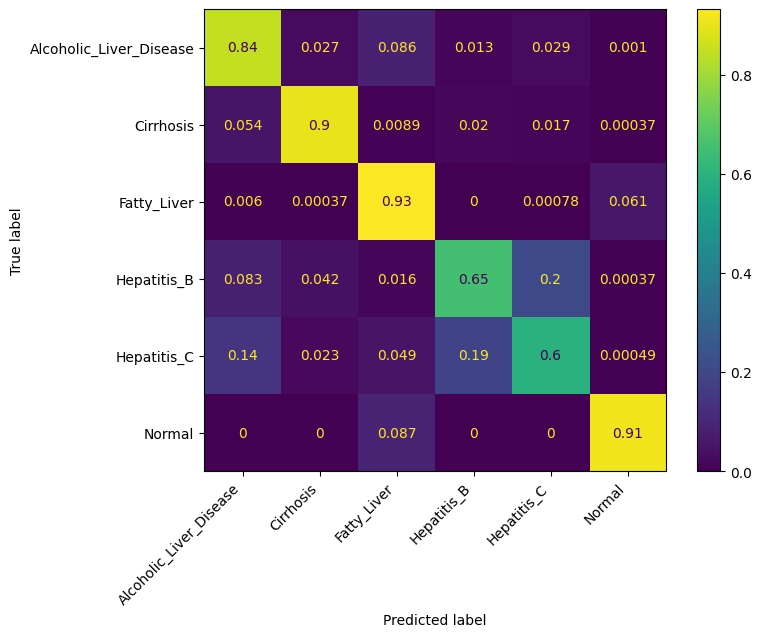

In [22]:
feature_importance_gbc = evaluate_pipeline(pipeline_gbc, X, y, additional="feature_importances_")

In [23]:
names = pipeline_gbc[0].get_feature_names_out()
feature_importance_df(feature_importance_gbc, names).head(10)

,feature,importance
20,remainder__ALT,0.221909
22,remainder__Bilirubin,0.196088
21,remainder__AST,0.156658
23,remainder__Albumin,0.074480
10,remainder__Sym_Fatigue,0.073778
11,remainder__Sym_Jaundice,0.069365
15,remainder__Sym_Dark_Urine,0.065016
14,remainder__Sym_Ascites,0.057050
24,remainder__Platelets,0.036095
17,remainder__Comorb_Diabetes,0.023076


Градиентный бустинг sklearn выдал схожую точность и хотя и другую важность признаков (ферменты важнее симптомов), но работал в 52 раза дольше (7 минут против 8 секунд)